# 🧠 PolitiSense Agent
## Multi-Agent Reasoning System for Verifying & Quantifying Tech Stock Volatility
**MS Data Science Final Project | University of North Texas**

---

## 👥 Team Roles & Responsibilities

| Member | Role | Core Responsibilities |
|--------|------|----------------------|
| Adithya Katari | Agentic AI Architect | Agent system design, orchestration pipeline, reasoning & verification loop |
| Satya Sree Bathina | Data Engineer | News data acquisition, cleaning, and preprocessing from GDELT & NewsAPI |
| Uday Gautamkumar Patel | NLP & Sentiment Engineer | Feature extraction, sentiment analysis, policy news classification |
| Venkata Rama Krishna Nallabelli | Quant & Visualization Lead | Financial data analysis, volatility modeling, dashboards |

## 1. Setup & Load <a id='1-setup'></a>

In [1]:
import csv
import datetime
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0f0f18',
    'axes.facecolor': '#16161f',
    'axes.edgecolor': '#333355',
    'axes.labelcolor': '#ccccdd',
    'xtick.color': '#888899',
    'ytick.color': '#888899',
    'text.color': '#e0e0ee',
    'grid.color': '#2a2a40',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'monospace',
})

CSV_PATH = 'whitehouse_presidential_actions_full.csv'

with open(CSV_PATH, encoding='utf-8-sig') as f:
    rows = list(csv.DictReader(f))

print(f'Loaded {len(rows)} rows')
print(f'Columns: {list(rows[0].keys())}')

Loaded 483 rows
Columns: ['post_id', 'title', 'url', 'categories', 'date_display', 'date_iso', 'content']


## 2. Basic Info <a id='2-basic-info'></a>

In [2]:
dates = sorted(r['date_iso'][:10] for r in rows if r['date_iso'])
null_content = sum(1 for r in rows if not r['content'].strip())

print(f"Total records  : {len(rows)}")
print(f"Date range     : {dates[0]}  →  {dates[-1]}")
print(f"Columns        : {len(rows[0])}")
print(f"Empty content  : {null_content}")
print()

# Preview
print("Sample rows:")
for r in rows[:3]:
    print(f"  [{r['date_iso'][:10]}] {r['title'][:70]}")

Total records  : 483
Date range     : 2025-01-20  →  2026-02-23
Columns        : 7
Empty content  : 1

Sample rows:
  [2026-02-23] National Angel Family Day, 2026
  [2026-02-20] Imposing a Temporary Import Surcharge to Address Fundamental Internati
  [2026-02-20] Continuing the Suspension of Duty-Free De Minimis Treatment for All Co


## 3. Action Types <a id='3-action-types'></a>

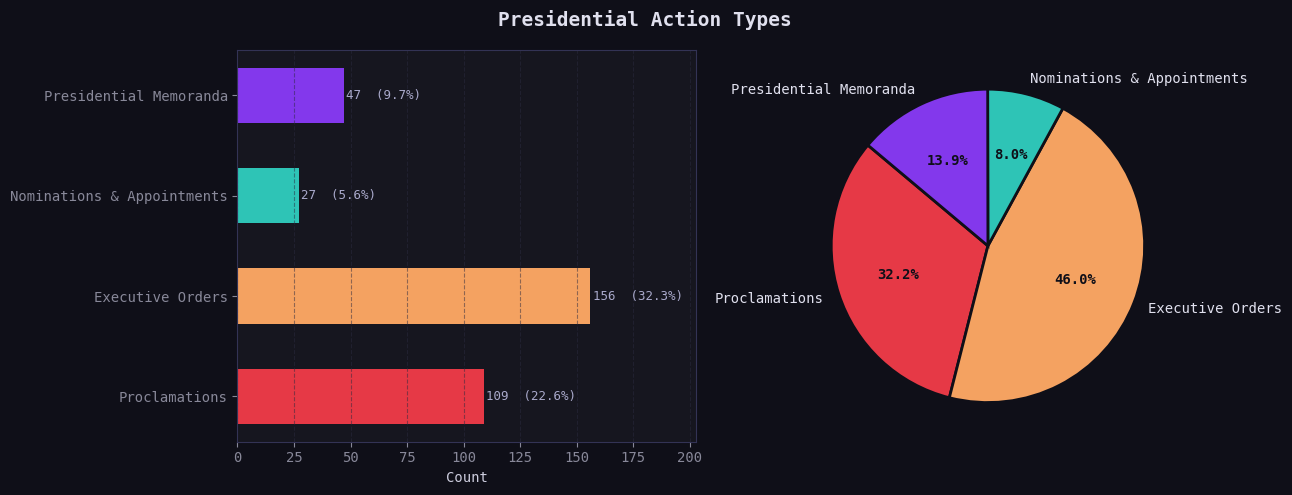


Type breakdown:
  Executive Orders                156  (32.3%)
  Proclamations                   109  (22.6%)
  Presidential Memoranda           47  (9.7%)
  Nominations & Appointments       27  (5.6%)


In [3]:
type_counts = Counter()
for r in rows:
    for cat in r['categories'].split(','):
        cat = cat.strip()
        if cat and cat != 'Presidential Actions':
            type_counts[cat] += 1

labels = list(type_counts.keys())
values = list(type_counts.values())
colors = ['#e63946', '#f4a261', '#2ec4b6', '#8338ec']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Presidential Action Types', fontsize=14, fontweight='bold', color='#e0e0ee')

# Bar chart
bars = ax1.barh(labels, values, color=colors, edgecolor='none', height=0.55)
ax1.set_xlabel('Count')
ax1.grid(axis='x')
for bar, val in zip(bars, values):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}  ({val/len(rows)*100:.1f}%)', va='center', fontsize=9, color='#aaaacc')
ax1.set_xlim(0, max(values) * 1.3)

# Pie chart
wedges, texts, autotexts = ax2.pie(
    values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='#0f0f18', linewidth=2)
)
for t in autotexts:
    t.set_color('#0f0f18')
    t.set_fontweight('bold')

plt.tight_layout()
plt.show()

print('\nType breakdown:')
for t, c in type_counts.most_common():
    print(f'  {t:<30} {c:>4}  ({c/len(rows)*100:.1f}%)')

## 4. Monthly Volume <a id='4-monthly-volume'></a>

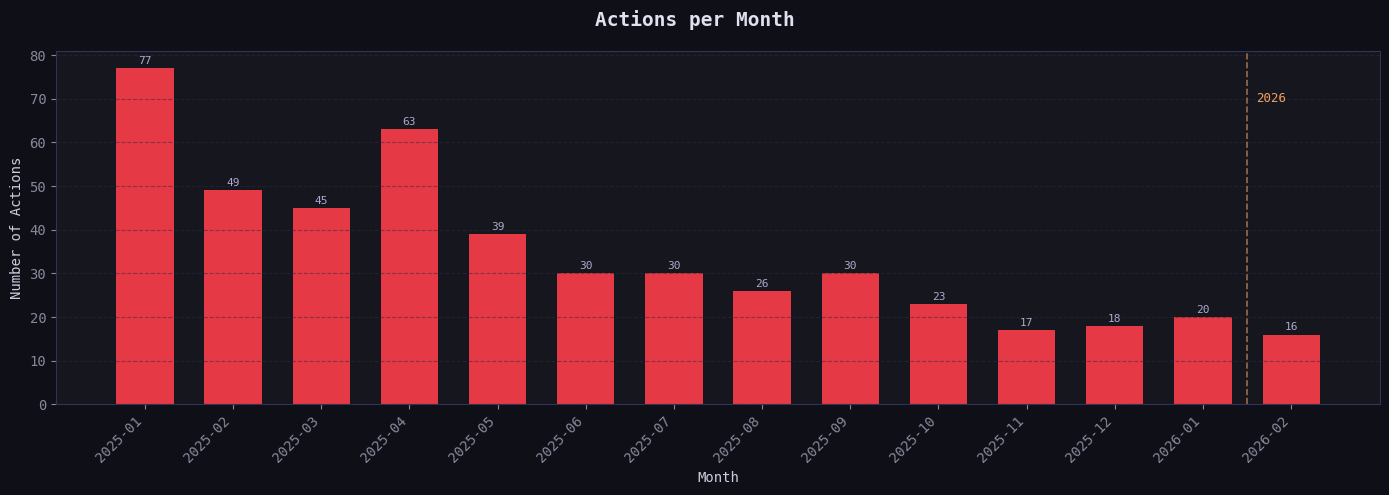

Peak month   : 2025-01 (77 actions)
Lowest month : 2026-02 (16 actions)


In [4]:
monthly = Counter(r['date_iso'][:7] for r in rows if r['date_iso'])
months = sorted(monthly.keys())
counts = [monthly[m] for m in months]

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Actions per Month', fontsize=14, fontweight='bold', color='#e0e0ee')

bars = ax.bar(months, counts, color='#e63946', edgecolor='none', width=0.65)

# Annotate
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            str(val), ha='center', va='bottom', fontsize=8, color='#aaaacc')

ax.set_xlabel('Month')
ax.set_ylabel('Number of Actions')
ax.grid(axis='y')
plt.xticks(rotation=45, ha='right')

# Shade year boundary
ax.axvline(x=12.5, color='#f4a261', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(12.6, max(counts)*0.9, '2026', color='#f4a261', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Peak month   : {max(monthly, key=monthly.get)} ({max(monthly.values())} actions)')
print(f'Lowest month : {min(monthly, key=monthly.get)} ({min(monthly.values())} actions)')

## 5. Day of Week Distribution <a id='5-day-of-week'></a>

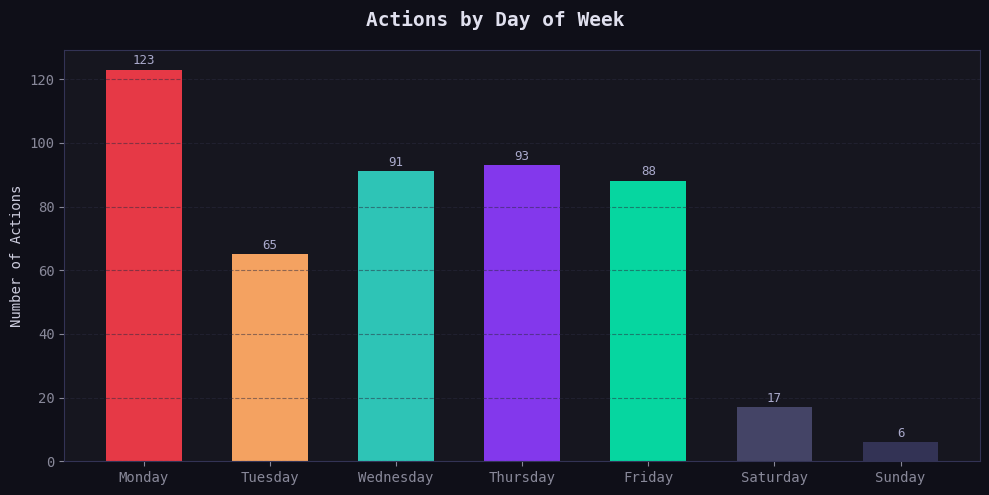

Weekday vs Weekend:
  Weekdays : 460 (95.2%)
  Weekends : 23 (4.8%)


In [5]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = Counter()
for r in rows:
    d = r['date_iso'][:10]
    if d:
        try:
            dow[datetime.date.fromisoformat(d).strftime('%A')] += 1
        except ValueError:
            pass

counts = [dow[d] for d in dow_order]
colors_dow = ['#e63946','#f4a261','#2ec4b6','#8338ec','#06d6a0','#444466','#333355']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Actions by Day of Week', fontsize=14, fontweight='bold', color='#e0e0ee')

bars = ax.bar(dow_order, counts, color=colors_dow, edgecolor='none', width=0.6)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
            str(val), ha='center', va='bottom', fontsize=9, color='#aaaacc')

ax.set_ylabel('Number of Actions')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print('Weekday vs Weekend:')
weekday = sum(dow[d] for d in dow_order[:5])
weekend = sum(dow[d] for d in dow_order[5:])
print(f'  Weekdays : {weekday} ({weekday/len(rows)*100:.1f}%)')
print(f'  Weekends : {weekend} ({weekend/len(rows)*100:.1f}%)')

## 6. Content Length Analysis <a id='6-content-length'></a>

Content Length Statistics (characters):
  Min    :        0
  Max    :   31,850
  Mean   :    6,153
  Median :    4,638
  Std    :    4,882
  Empty  :        1


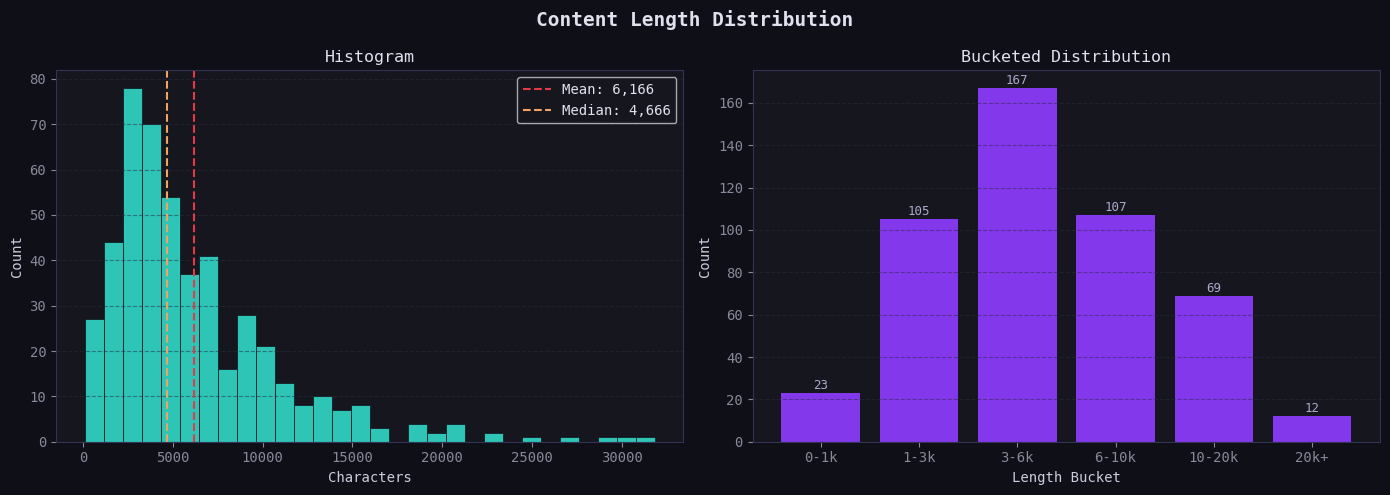

In [6]:
lengths = [len(r['content']) for r in rows]
lengths_nz = [l for l in lengths if l > 0]

print('Content Length Statistics (characters):')
print(f'  Min    : {min(lengths):>8,}')
print(f'  Max    : {max(lengths):>8,}')
print(f'  Mean   : {int(np.mean(lengths)):>8,}')
print(f'  Median : {int(np.median(lengths)):>8,}')
print(f'  Std    : {int(np.std(lengths)):>8,}')
print(f'  Empty  : {lengths.count(0):>8}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Content Length Distribution', fontsize=14, fontweight='bold', color='#e0e0ee')

# Histogram
ax1.hist(lengths_nz, bins=30, color='#2ec4b6', edgecolor='#0f0f18', linewidth=0.5)
ax1.axvline(np.mean(lengths_nz), color='#e63946', linewidth=1.5, linestyle='--', label=f'Mean: {int(np.mean(lengths_nz)):,}')
ax1.axvline(np.median(lengths_nz), color='#f4a261', linewidth=1.5, linestyle='--', label=f'Median: {int(np.median(lengths_nz)):,}')
ax1.set_xlabel('Characters')
ax1.set_ylabel('Count')
ax1.set_title('Histogram')
ax1.legend()
ax1.grid(axis='y')

# Bucket bar chart
bucket_labels = ['0-1k', '1-3k', '3-6k', '6-10k', '10-20k', '20k+']
buckets = [0, 1000, 3000, 6000, 10000, 20000, 99999]
bucket_counts = [sum(1 for l in lengths if buckets[i] <= l < buckets[i+1]) for i in range(len(bucket_labels))]

ax2.bar(bucket_labels, bucket_counts, color='#8338ec', edgecolor='none')
for i, (bar_x, val) in enumerate(zip(bucket_labels, bucket_counts)):
    ax2.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9, color='#aaaacc')
ax2.set_xlabel('Length Bucket')
ax2.set_ylabel('Count')
ax2.set_title('Bucketed Distribution')
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

## 7. Top Title Keywords <a id='7-keywords'></a>

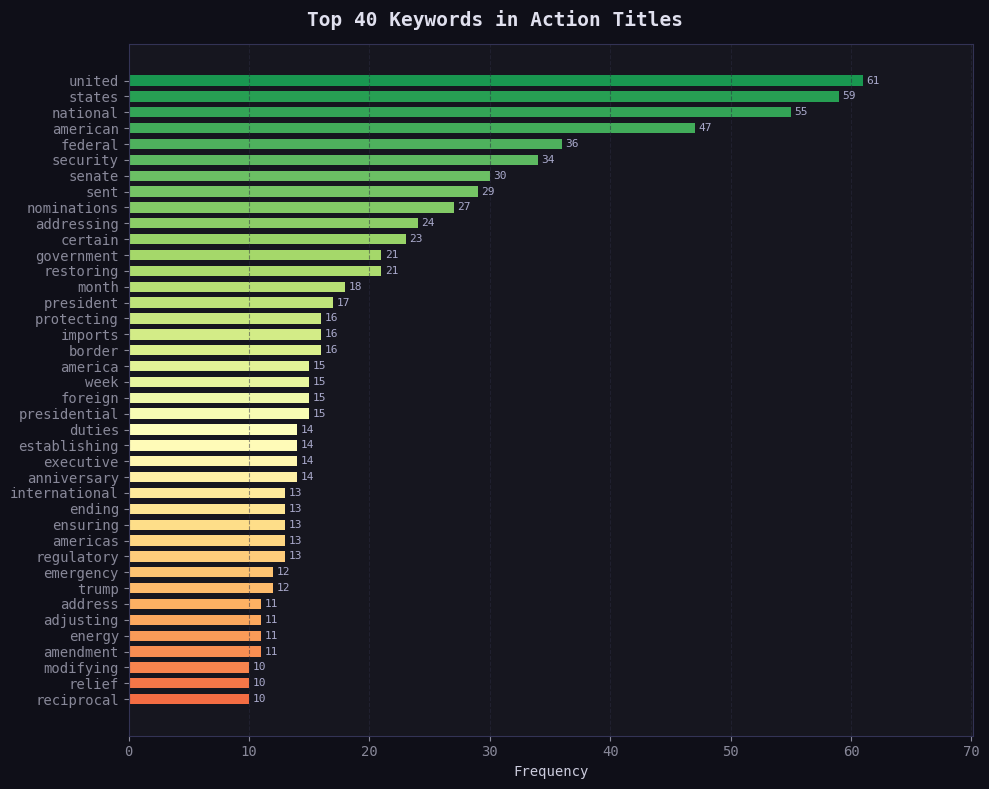

In [7]:
stopwords = {
    'of','the','a','and','to','in','for','on','an','by','with','from',
    'at','or','as','is','be','its','all','into','new','our','this',
    'that','are','not','act','2025','2026'
}
words = Counter()
for r in rows:
    for w in r['title'].lower().split():
        w = re.sub(r'[^a-z]', '', w)
        if len(w) > 3 and w not in stopwords:
            words[w] += 1

top_n = 40
top_words = words.most_common(top_n)
kw_labels = [w for w, _ in reversed(top_words)]
kw_vals = [c for _, c in reversed(top_words)]

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f'Top {top_n} Keywords in Action Titles', fontsize=14, fontweight='bold', color='#e0e0ee')

gradient_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, top_n))
bars = ax.barh(kw_labels, kw_vals, color=gradient_colors, edgecolor='none', height=0.65)
for bar, val in zip(bars, kw_vals):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8, color='#aaaacc')

ax.set_xlabel('Frequency')
ax.grid(axis='x')
ax.set_xlim(0, max(kw_vals) * 1.15)

plt.tight_layout()
plt.show()

## 8. Avg Content Length by Action Type <a id='8-avg-length-by-type'></a>

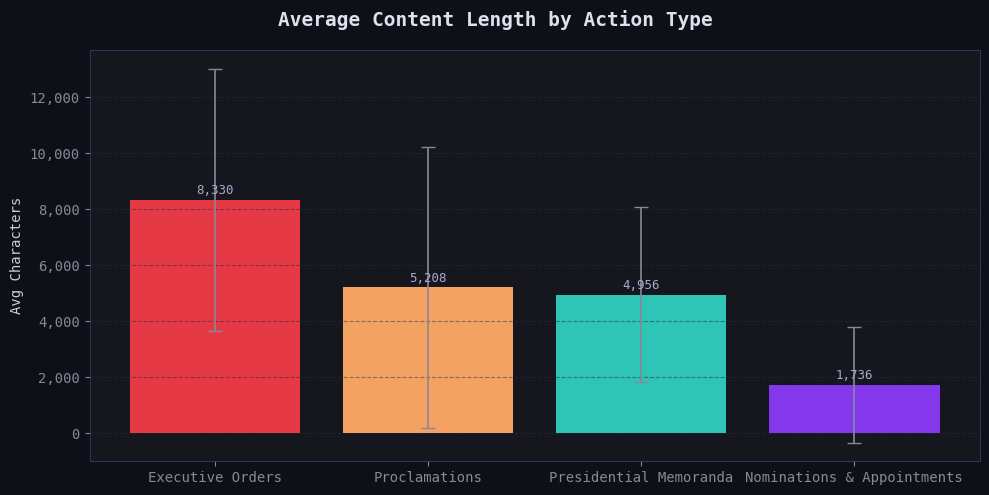

Summary:
  Executive Orders               avg=  8,330  std=  4,684  n=156
  Proclamations                  avg=  5,208  std=  5,028  n=109
  Presidential Memoranda         avg=  4,956  std=  3,118  n=47
  Nominations & Appointments     avg=  1,736  std=  2,063  n=27


In [8]:
type_lengths = {}
for r in rows:
    for cat in r['categories'].split(','):
        cat = cat.strip()
        if cat and cat != 'Presidential Actions':
            type_lengths.setdefault(cat, []).append(len(r['content']))

type_avgs = {k: int(np.mean(v)) for k, v in type_lengths.items()}
type_stds = {k: int(np.std(v)) for k, v in type_lengths.items()}
sorted_types = sorted(type_avgs, key=type_avgs.get, reverse=True)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Average Content Length by Action Type', fontsize=14, fontweight='bold', color='#e0e0ee')

avgs = [type_avgs[t] for t in sorted_types]
stds = [type_stds[t] for t in sorted_types]
bars = ax.bar(sorted_types, avgs, color=['#e63946','#f4a261','#2ec4b6','#8338ec'],
              edgecolor='none', yerr=stds, capsize=5,
              error_kw=dict(ecolor='#888899', linewidth=1.2))

for bar, val in zip(bars, avgs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9, color='#aaaacc')

ax.set_ylabel('Avg Characters')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print('Summary:')
for t in sorted_types:
    print(f'  {t:<30} avg={type_avgs[t]:>7,}  std={type_stds[t]:>7,}  n={len(type_lengths[t])}')

## 9. Busiest Weeks <a id='9-busiest-weeks'></a>

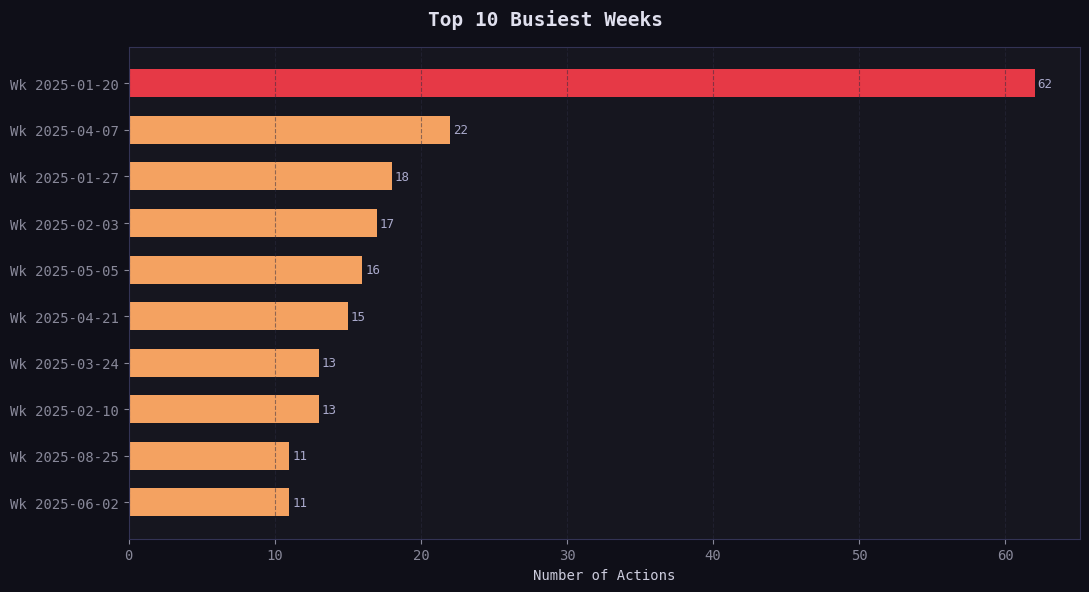

Top 10 busiest weeks:
  Week of 2025-01-20: 62 actions
  Week of 2025-04-07: 22 actions
  Week of 2025-01-27: 18 actions
  Week of 2025-02-03: 17 actions
  Week of 2025-05-05: 16 actions
  Week of 2025-04-21: 15 actions
  Week of 2025-03-24: 13 actions
  Week of 2025-02-10: 13 actions
  Week of 2025-08-25: 11 actions
  Week of 2025-06-02: 11 actions


In [9]:
weekly = Counter()
for r in rows:
    d = r['date_iso'][:10]
    if d:
        try:
            dt = datetime.date.fromisoformat(d)
            week_start = dt - datetime.timedelta(days=dt.weekday())
            weekly[str(week_start)] += 1
        except ValueError:
            pass

top_weeks = weekly.most_common(10)
wk_labels = [f"Wk {w}" for w, _ in reversed(top_weeks)]
wk_vals = [c for _, c in reversed(top_weeks)]

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Top 10 Busiest Weeks', fontsize=14, fontweight='bold', color='#e0e0ee')

colors_w = ['#e63946' if v == max(wk_vals) else '#f4a261' for v in wk_vals]
bars = ax.barh(wk_labels, wk_vals, color=colors_w, edgecolor='none', height=0.6)
for bar, val in zip(bars, wk_vals):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color='#aaaacc')

ax.set_xlabel('Number of Actions')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

print('Top 10 busiest weeks:')
for w, c in top_weeks:
    print(f'  Week of {w}: {c} actions')

## 10. Quarterly Summary <a id='10-quarterly-summary'></a>

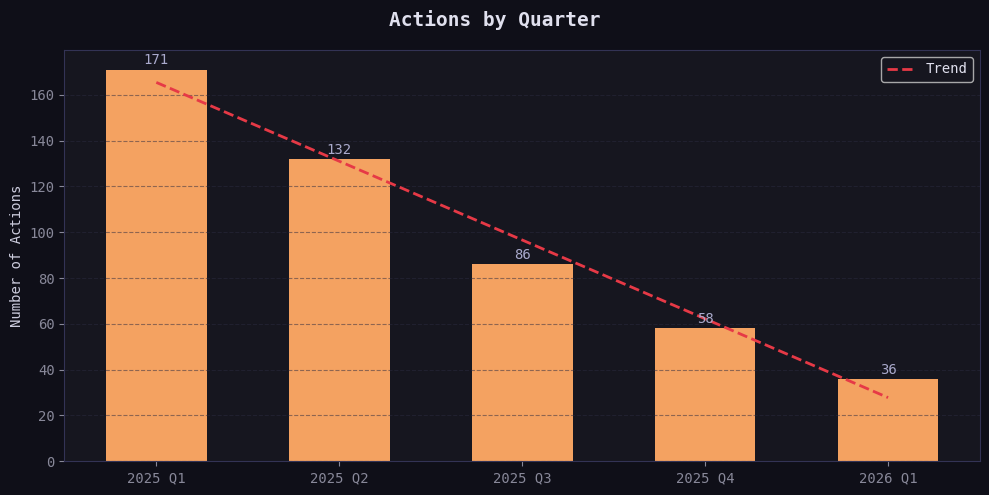

Quarterly counts:
  2025 Q1   171  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2025 Q2   132  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2025 Q3    86  ██████████████████████████████████████████████████████████████████████████████████████
  2025 Q4    58  ██████████████████████████████████████████████████████████
  2026 Q1    36  ████████████████████████████████████


In [10]:
quarters = Counter()
for r in rows:
    d = r['date_iso'][:7]
    if d:
        year, month = d.split('-')
        q = (int(month) - 1) // 3 + 1
        quarters[f"{year} Q{q}"] += 1

q_labels = sorted(quarters.keys())
q_vals = [quarters[q] for q in q_labels]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Actions by Quarter', fontsize=14, fontweight='bold', color='#e0e0ee')

bars = ax.bar(q_labels, q_vals, color='#f4a261', edgecolor='none', width=0.55)
for bar, val in zip(bars, q_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            str(val), ha='center', va='bottom', fontsize=10, color='#aaaacc')

ax.set_ylabel('Number of Actions')
ax.grid(axis='y')

# Trend line
x = np.arange(len(q_labels))
z = np.polyfit(x, q_vals, 1)
p = np.poly1d(z)
ax.plot(q_labels, p(x), color='#e63946', linewidth=2, linestyle='--', label='Trend')
ax.legend()

plt.tight_layout()
plt.show()

print('Quarterly counts:')
for q, c in zip(q_labels, q_vals):
    bar = '█' * c
    print(f'  {q}  {c:>4}  {bar}')